In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)


TensorFlow version: 2.18.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
# ===============================
# 1️ Imports
# ===============================
import tensorflow as tf
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# ===============================
# 2️ Load Dataset
# ===============================
dataset_path = "/kaggle/input/rsna-bone-age"
train_labels = pd.read_csv(f"{dataset_path}/boneage-training-dataset.csv")

# Fix gender column
train_labels['sex'] = train_labels['male'].map({False:'Female', True:'Male'})

# ===============================
# 3️ Create Class Labels from Bone Age
# ===============================
# Example bins (you can adjust based on dataset)
bins = [0, 24, 72, 120, 180, 228]
labels = ['Infant','Child','Pre-Adolescent','Adolescent','Adult-like']

train_labels['age_group'] = pd.cut(train_labels['boneage'], bins=bins, labels=labels)

# Encode labels
le = LabelEncoder()
train_labels['age_group_encoded'] = le.fit_transform(train_labels['age_group'])
num_classes = len(le.classes_)

# ===============================
# 4️ Create File Paths
# ===============================
train_folder = f"{dataset_path}/boneage-training-dataset/boneage-training-dataset"

train_labels['file_path'] = train_labels['id'].apply(lambda x: os.path.join(
    train_folder, [f for f in os.listdir(train_folder) if f.startswith(str(x))][0]
))

# ===============================
# 5️ TensorFlow Preprocessing Function
# ===============================
IMG_SIZE = (224, 224)

def preprocess_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    label = tf.one_hot(label, num_classes)
    return img, label

# ===============================
# 6️ Train-Validation Split
# ===============================
file_paths = train_labels['file_path'].values
labels_encoded = train_labels['age_group_encoded'].values

train_paths, val_paths, train_labels_arr, val_labels_arr = train_test_split(
    file_paths, labels_encoded, test_size=0.1, random_state=42, stratify=labels_encoded
)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels_arr))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("GPU-enabled classification dataset ready!")


GPU-enabled classification dataset ready!


I0000 00:00:1764694902.447023      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764694902.447696      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

IMG_SIZE = (224, 224)
num_classes = len(train_labels['age_group'].unique())

# Load pretrained MobileNetV2 (no top)
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base initially

# Add custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10


I0000 00:00:1764694921.790714     110 service.cc:148] XLA service 0x7c6064212cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764694921.791644     110 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764694921.791668     110 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764694922.737051     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/355 ━━━━━━━━━━━━━━━━━━━━ 2:13:28 23s/step - accuracy: 0.1250 - loss: 2.0079

I0000 00:00:1764694927.498662     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


355/355 ━━━━━━━━━━━━━━━━━━━━ 123s 322ms/step - accuracy: 0.6878 - loss: 0.7433 - val_accuracy: 0.7092 - val_loss: 0.6970
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 294ms/step - accuracy: 0.6909 - loss: 0.7234 - val_accuracy: 0.7076 - val_loss: 0.6868
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 297ms/step - accuracy: 0.7253 - loss: 0.6573 - val_accuracy: 0.7163 - val_loss: 0.6491
Epoch 10/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 124s 324ms/step - accuracy: 0.7348 - loss: 0.6377 - val_accuracy: 0.7179 - val_loss: 0.6535


In [6]:
# Unfreeze some layers
base_model.trainable = True

# Compile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
fine_tune_epochs = 5
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)


Epoch 10/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 120s 313ms/step - accuracy: 0.7116 - loss: 0.6822 - val_accuracy: 0.6799 - val_loss: 0.7574
Epoch 12/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 311ms/step - accuracy: 0.7488 - loss: 0.5888 - val_accuracy: 0.7013 - val_loss: 0.7190
Epoch 13/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 311ms/step - accuracy: 0.7810 - loss: 0.5273 - val_accuracy: 0.7036 - val_loss: 0.7035
Epoch 14/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 309ms/step - accuracy: 0.8014 - loss: 0.4872 - val_accuracy: 0.6846 - val_loss: 0.7565
Epoch 15/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 142s 310ms/step - accuracy: 0.8227 - loss: 0.4384 - val_accuracy: 0.6220 - val_loss: 0.8670


40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 325ms/step
                precision    recall  f1-score   support

    Adolescent       0.84      0.57      0.68       665
    Adult-like       0.81      0.37      0.51        68
         Child       0.54      0.91      0.68       142
        Infant       0.50      0.24      0.32        17
Pre-Adolescent       0.47      0.67      0.55       370

      accuracy                           0.62      1262
     macro avg       0.63      0.55      0.55      1262
  weighted avg       0.69      0.62      0.63      1262



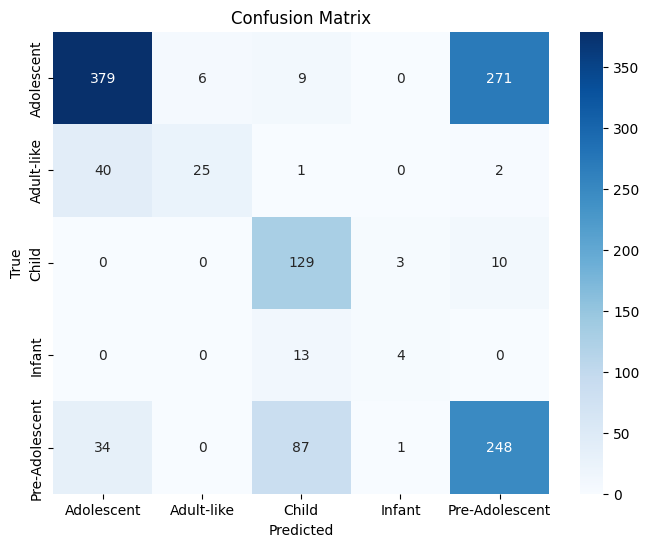

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Predictions
y_true = np.concatenate([y for x,y in val_ds])
y_pred = model.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Accuracy & Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop]
)


Epoch 1/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 120s 312ms/step - accuracy: 0.8439 - loss: 0.3888 - val_accuracy: 0.6006 - val_loss: 0.9187
Epoch 2/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 129s 338ms/step - accuracy: 0.8592 - loss: 0.3577 - val_accuracy: 0.5816 - val_loss: 0.9567
Epoch 3/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 310ms/step - accuracy: 0.8816 - loss: 0.3155 - val_accuracy: 0.6228 - val_loss: 0.8743
Epoch 4/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 311ms/step - accuracy: 0.8932 - loss: 0.2829 - val_accuracy: 0.6300 - val_loss: 0.8766
Epoch 5/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 120s 312ms/step - accuracy: 0.9103 - loss: 0.2513 - val_accuracy: 0.6680 - val_loss: 0.8363
Epoch 6/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 309ms/step - accuracy: 0.9367 - loss: 0.1859 - val_accuracy: 0.6854 - val_loss: 0.8385
Epoch 8/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 309ms/step - accuracy: 0.9488 - loss: 0.1604 - val_accuracy: 0.6973 - val_loss: 0.8880
Epoch 10/25
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 310ms/step - accuracy: 0.9550 

In [14]:
class_names = [
    "Infant",
    "Child",
    "Pre-Adolescent",
    "Adolescent",
    "Adult-like"
]

print(class_names)


['Infant', 'Child', 'Pre-Adolescent', 'Adolescent', 'Adult-like']


In [10]:
from sklearn.metrics import classification_report
import numpy as np

# Predict
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)

# Convert y_true to integer labels
y_true = np.concatenate([y.numpy() for _, y in val_ds])
if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)  # <- this line fixes the error

# Class names
class_names = ["Infant", "Child", "Pre-Adolescent", "Adolescent", "Adult-like"]

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))


40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step
                precision    recall  f1-score   support

        Infant       0.84      0.83      0.84       665
         Child       0.68      0.68      0.68        68
Pre-Adolescent       0.72      0.72      0.72       142
    Adolescent       0.59      0.59      0.59        17
    Adult-like       0.68      0.70      0.69       370

      accuracy                           0.77      1262
     macro avg       0.70      0.70      0.70      1262
  weighted avg       0.77      0.77      0.77      1262



40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step


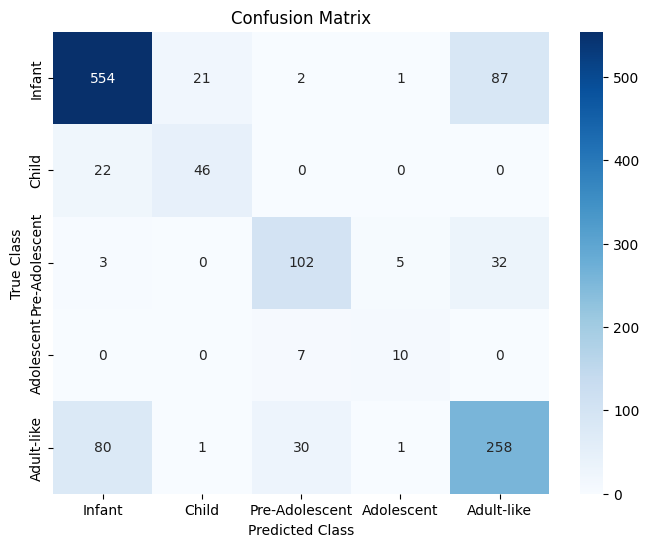

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get true labels (convert from one-hot if needed)
y_true = np.concatenate([np.argmax(y.numpy(), axis=-1) if len(y.shape) > 1 else y.numpy() for _, y in val_ds])
# Get predicted labels
y_pred = np.argmax(model.predict(val_ds), axis=-1)

# Define class names manually
class_names = ['Infant', 'Child', 'Pre-Adolescent', 'Adolescent', 'Adult-like']

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()


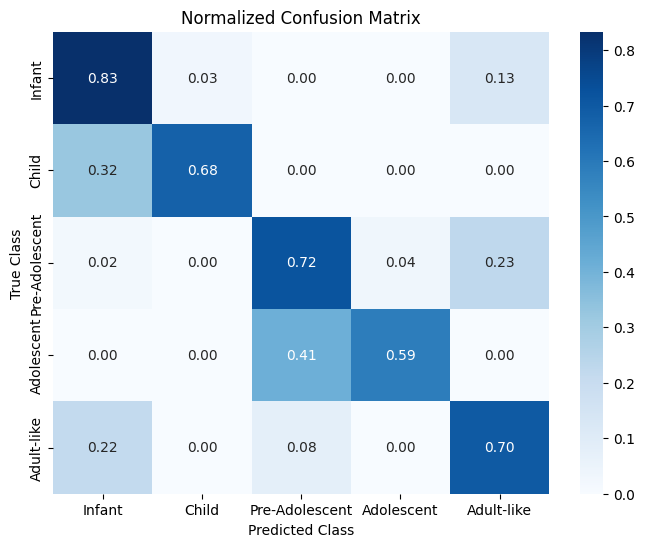

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


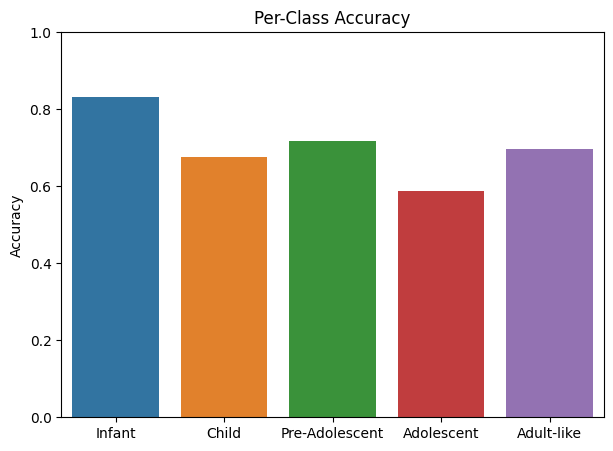

In [ ]:
# ===============================
# 1️ Normalized Confusion Matrix
# ===============================
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-wise normalization

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Normalized Confusion Matrix')
plt.show()


# ===============================
# 2️ Per-Class Accuracy Bar Plot
# ===============================
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7,5))
sns.barplot(x=class_names, y=per_class_acc)
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.show()


In [15]:
# 1. compute integer labels for train set (works if train_ds yields one-hot labels)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Extract integer labels from train_ds
y_train = np.concatenate([np.argmax(y.numpy(), axis=-1) for _, y in train_ds])
print("Unique train labels:", np.unique(y_train), "counts:", np.bincount(y_train))

# Compute class weights (balanced)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(enumerate(weights))
print("class_weight:", class_weight)


Unique train labels: [0 1 2 3 4] counts: [5985  613 1276  151 3324]
class_weight: {0: 0.3792481203007519, 1: 3.702773246329527, 2: 1.7788401253918495, 3: 15.031788079470198, 4: 0.6828519855595668}


In [17]:
import tensorflow as tf
from tensorflow.keras import layers

# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.06),
])

# Apply augmentation to training dataset (before batching if needed)
# If your train_ds is already batched, apply augmentation inside map (works with batched tensors)
aug_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                            num_parallel_calls=tf.data.AUTOTUNE)
# Use augmented dataset for training


In [20]:
# Unfreeze only last 30 layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with LOW learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    aug_train_ds,          
    validation_data=val_ds,
    epochs=10,             
    callbacks=[early_stop]
)


Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 173s 416ms/step - accuracy: 0.4705 - loss: 1.2482 - val_accuracy: 0.5420 - val_loss: 0.9887
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 150s 396ms/step - accuracy: 0.6259 - loss: 0.8804 - val_accuracy: 0.5721 - val_loss: 0.9213
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 150s 395ms/step - accuracy: 0.6565 - loss: 0.8265 - val_accuracy: 0.6260 - val_loss: 0.8468
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 149s 394ms/step - accuracy: 0.6649 - loss: 0.7807 - val_accuracy: 0.6799 - val_loss: 0.7505
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 149s 395ms/step - accuracy: 0.6859 - loss: 0.7408 - val_accuracy: 0.6997 - val_loss: 0.7104
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 151s 398ms/step - accuracy: 0.7041 - loss: 0.7088 - val_accuracy: 0.7116 - val_loss: 0.6891
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 158s 419ms/step - accuracy: 0.7082 - loss: 0.7031 - val_accuracy: 0.7171 - val_loss: 0.6736
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 155s 411ms/step - accuracy: 0.7184 -

In [22]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=-1) for _, y in val_ds])

qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print("QWK :", qwk)


40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 331ms/step
QWK : 0.5325065532343021
